In [1]:
from datadlc import DataDLC
from plotting import Plotting

#### 1: DataDLC

In [2]:
data_dlc = DataDLC(
    r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3740_convertedDLC_Resnet50_td_res50_2Mar13shuffle1_detector_200_snapshot_075.h5"
    )

In [3]:
data_dlc.impute_outliers(method='square_ransac',
                         model="HGBR",
                         min_samples=20,
                         residual_threshold=0.05,
                         max_trials=1000)

In [4]:
data_dlc.get_bending_coefficients()

0       0.001499
1       0.001399
2       0.001385
3       0.001381
4       0.001238
          ...   
2071    0.021115
2072    0.021578
2073    0.018366
2074    0.000176
2075    0.018743
Name: Bending_Coefficient, Length: 2076, dtype: float64

In [5]:
data_dlc.apply_homography()

,tf_FR1_x,tf_FR1_y,tf_FR2_x,tf_FR2_y,tf_FG1_x,tf_FG1_y,tf_FG2_x,tf_FG2_y,tf_FB1_x,tf_FB1_y,tf_FB2_x,tf_FB2_y
0,-17.803667,-11.622228,-3.359524,10.294960,13.096483,30.284790,30.738260,48.827766,46.880558,65.741341,64.123466,80.845375
1,-15.282809,-10.716719,-0.624602,11.268978,15.093939,30.405006,33.036678,49.808456,49.254658,67.337669,65.794296,82.036758
2,-10.629069,-8.812232,1.833454,10.228296,18.986572,31.227276,35.363926,50.404011,51.375885,67.806892,68.357147,83.351311
3,-7.477637,-8.500248,6.726527,13.314097,22.147902,33.277767,39.407639,52.726498,55.775372,70.912964,71.796310,86.350548
4,-5.712757,-6.753500,9.908044,15.354982,26.146423,37.081974,41.723621,54.813892,59.162544,74.984062,74.991493,89.650665
...,...,...,...,...,...,...,...,...,...,...,...,...
2071,191.737991,96.244415,97.090981,91.091888,97.984909,92.335335,141.302124,145.827835,141.536560,145.177612,144.239105,145.732819
2072,191.994461,96.139938,97.809418,91.142624,98.429756,92.605286,141.611313,146.395355,141.780502,145.926529,143.491119,145.911560
2073,191.759384,96.422813,97.738350,90.930244,98.379860,92.410637,202.282501,195.869446,194.248871,102.657402,105.844147,112.755043
2074,191.969589,96.246460,98.133682,90.639618,98.795425,92.306847,202.217743,195.906082,137.385147,147.070511,141.539108,148.694778


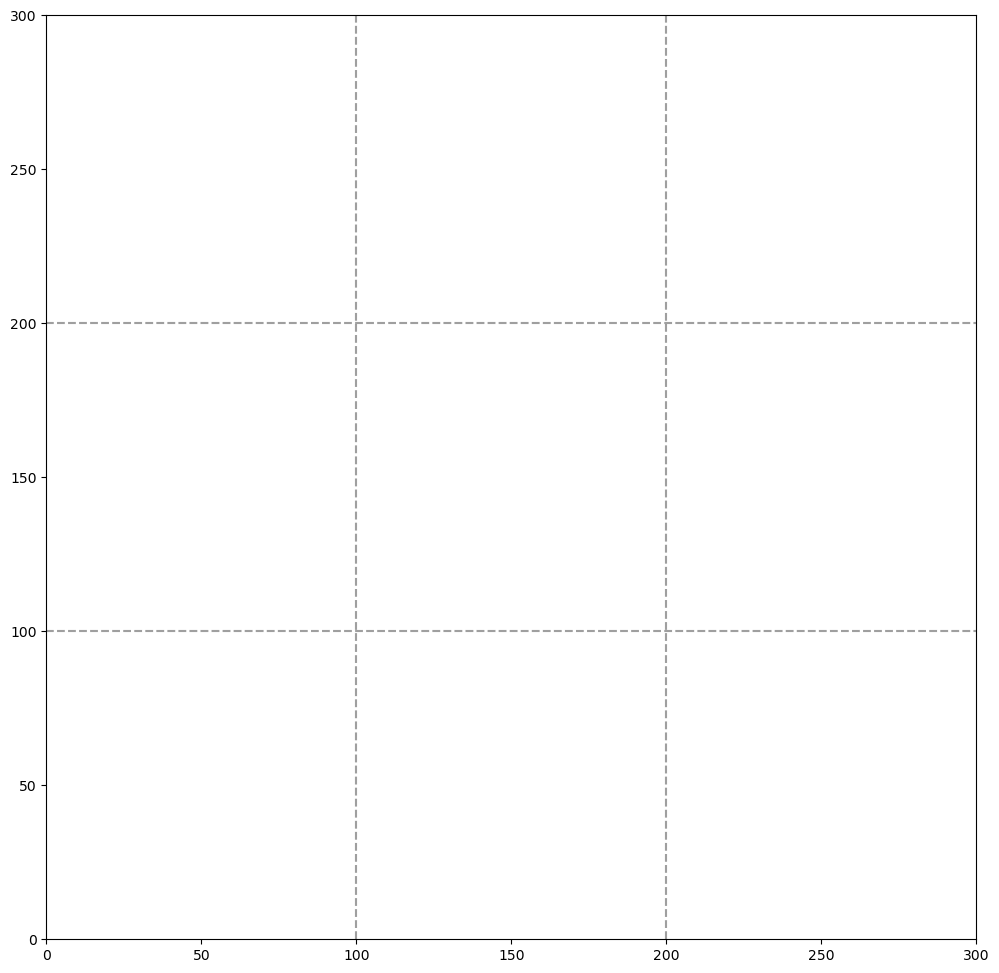

In [6]:
Plotting.plot_homography_animated(data_dlc.homography_points,
                                  data_dlc.df_transformed_monofil,
                                  "homography_animation_3740.mp4")

In [6]:
data_dlc._get_homography_matrix(5)

array([[ 5.04052540e-01, -2.06344037e-02, -2.01491044e+02],
       [ 4.18465632e-02,  8.05835322e-01, -1.40987884e+02],
       [-6.78631872e-04,  6.18835899e-04,  1.00000000e+00]])

#### 2: DataNeuron

In [7]:
from dataneuron import DataNeuron

In [8]:
data_neuron = DataNeuron(
    r"C:\Python Programming\LIU\Data\nerve accel data\20250306_MP_018_radial_2Sel_unit_6_RF_mapp_1_3740.xlsx",
    100000
    )

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\dataneuron.py:59: RuntimeWarning: divide by zero encountered in scalar divide
  current_freq = 1 / np.mean(time_diffs).round()


In [9]:
data_neuron.df.head()

,Time,Spikes,IFF
0,0.00000,0,0.0
1,0.00001,0,0.0
2,0.00002,0,0.0
3,0.00003,0,0.0
4,0.00004,0,0.0


In [10]:
data_neuron.df[1:]

,Time,Spikes,IFF
1,0.00001,0,0.000000
2,0.00002,0,0.000000
3,0.00003,0,0.000000
4,0.00004,0,0.000000
5,0.00005,0,0.000000
...,...,...,...
6905035,69.04842,0,16.433853
6905036,69.04843,0,16.433853
6905037,69.04844,0,16.433853
6905038,69.04845,1,16.433853


c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


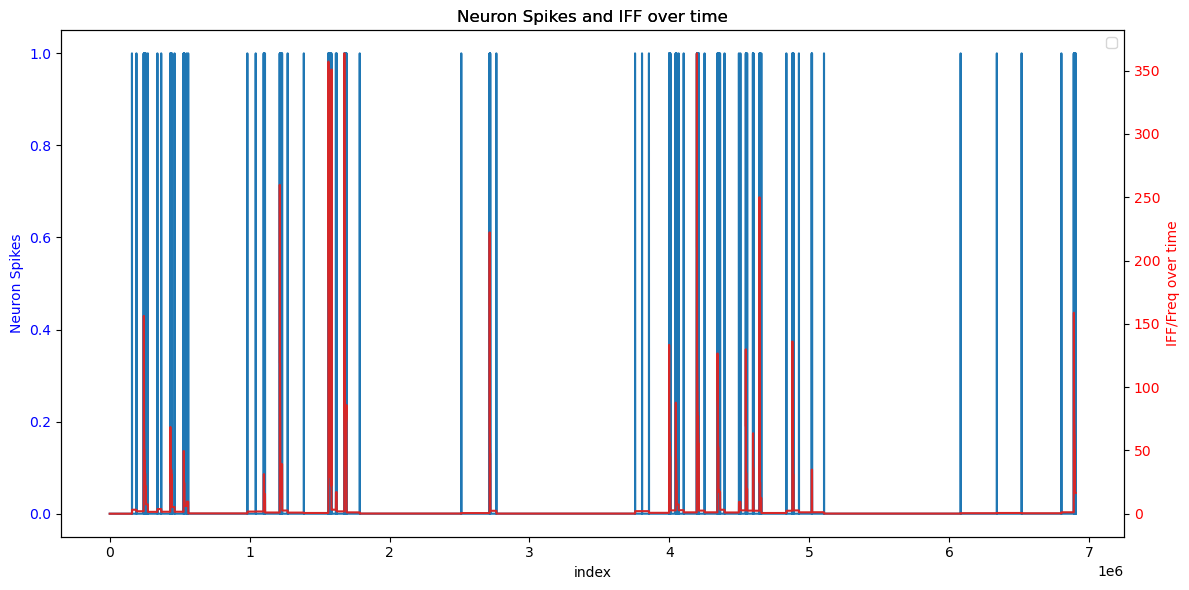

In [11]:
columns = data_neuron.df.columns

Plotting.plot_lines(data_neuron.df,
                    columns[1:],
                    xlabel="index",
                    ylabel_1="Neuron Spikes",
                    ylabel_2="IFF/Freq over time",
                    title="Neuron Spikes and IFF over time")

In [12]:
data_neuron.downsample(30) 

3333


,IFF,Spikes
0,0.000000,0.0
1,0.000000,0.0
2,0.000000,0.0
3,0.000000,0.0
4,0.000000,0.0
...,...,...
2067,1.129943,0.0
2068,158.730164,3.0
2069,101.010101,3.0
2070,61.728394,2.0


c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


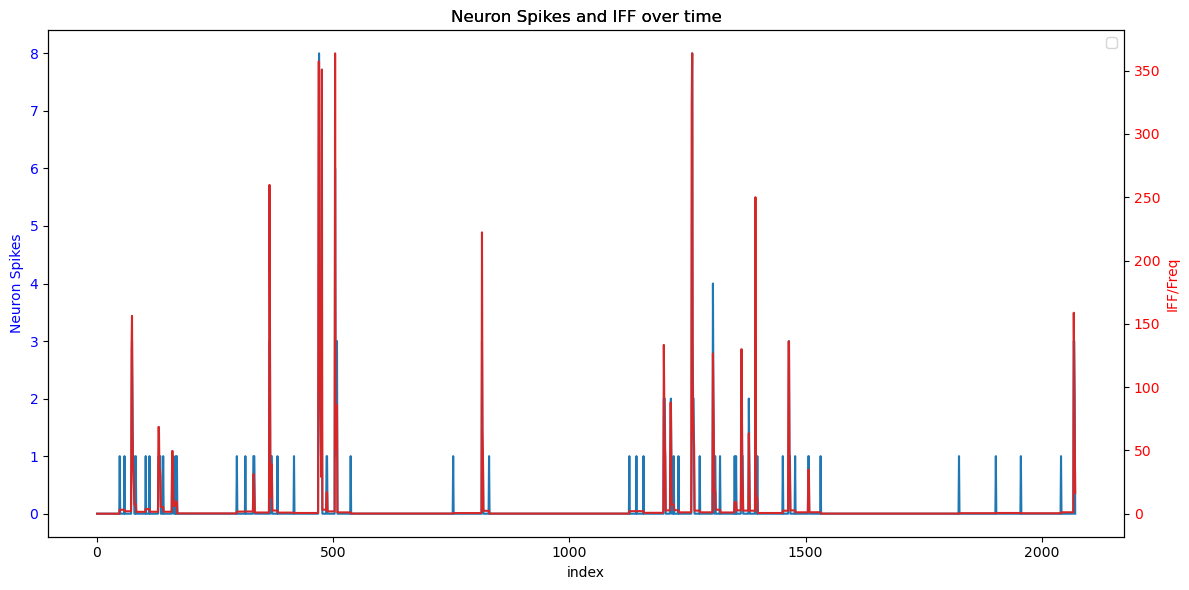

In [13]:
Plotting.plot_lines(data_neuron.downsampled_df,
                    columns[1:],
                    "index", "Neuron Spikes", "IFF/Freq",
                    "Neuron Spikes and IFF over time")

#### 3: MergeData

In [14]:
from mergeddata import MergedData

In [15]:
full_data = MergedData(data_dlc, data_neuron)

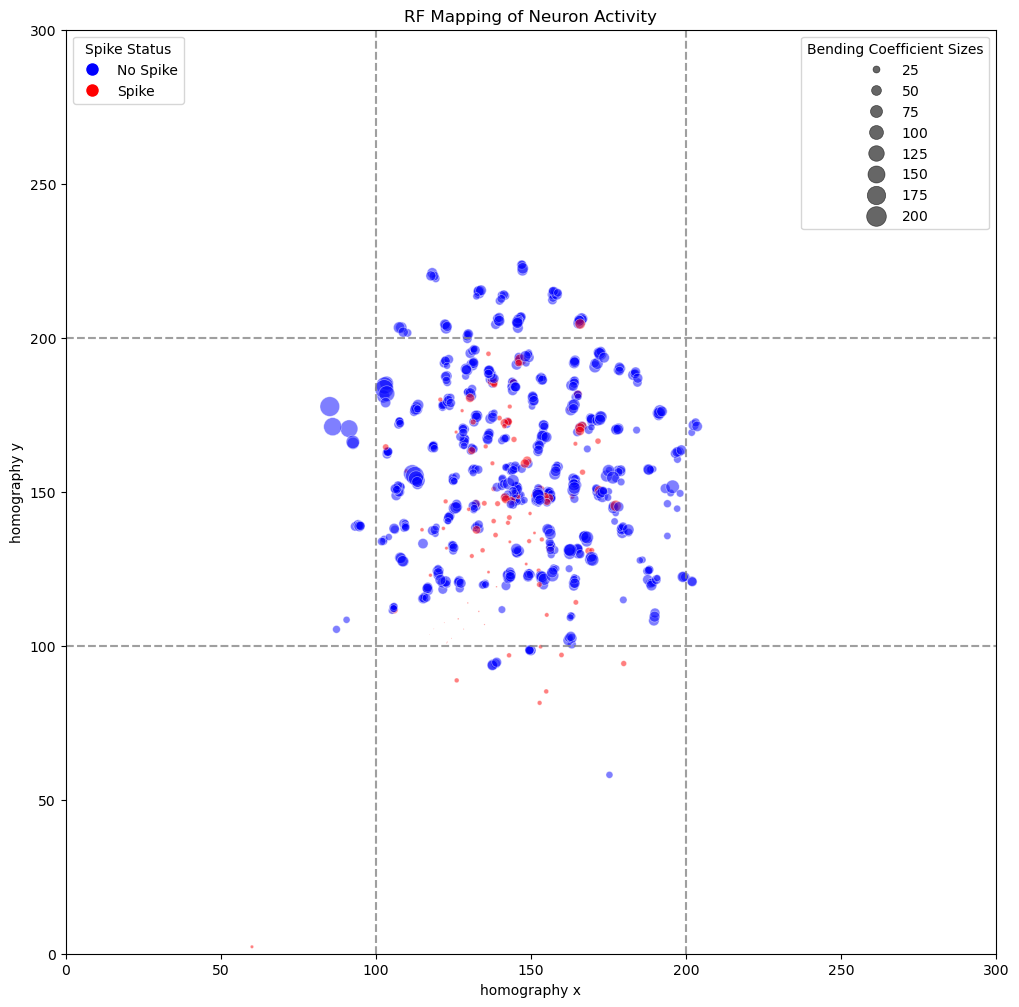

In [ ]:
Plotting.plot_rf_mapping(full_data,
                         "tf_FB2_x", "tf_FB2_y",
                         "Bending_Coefficient",
                         "Spikes",
                         full_data.dlc.homography_points)

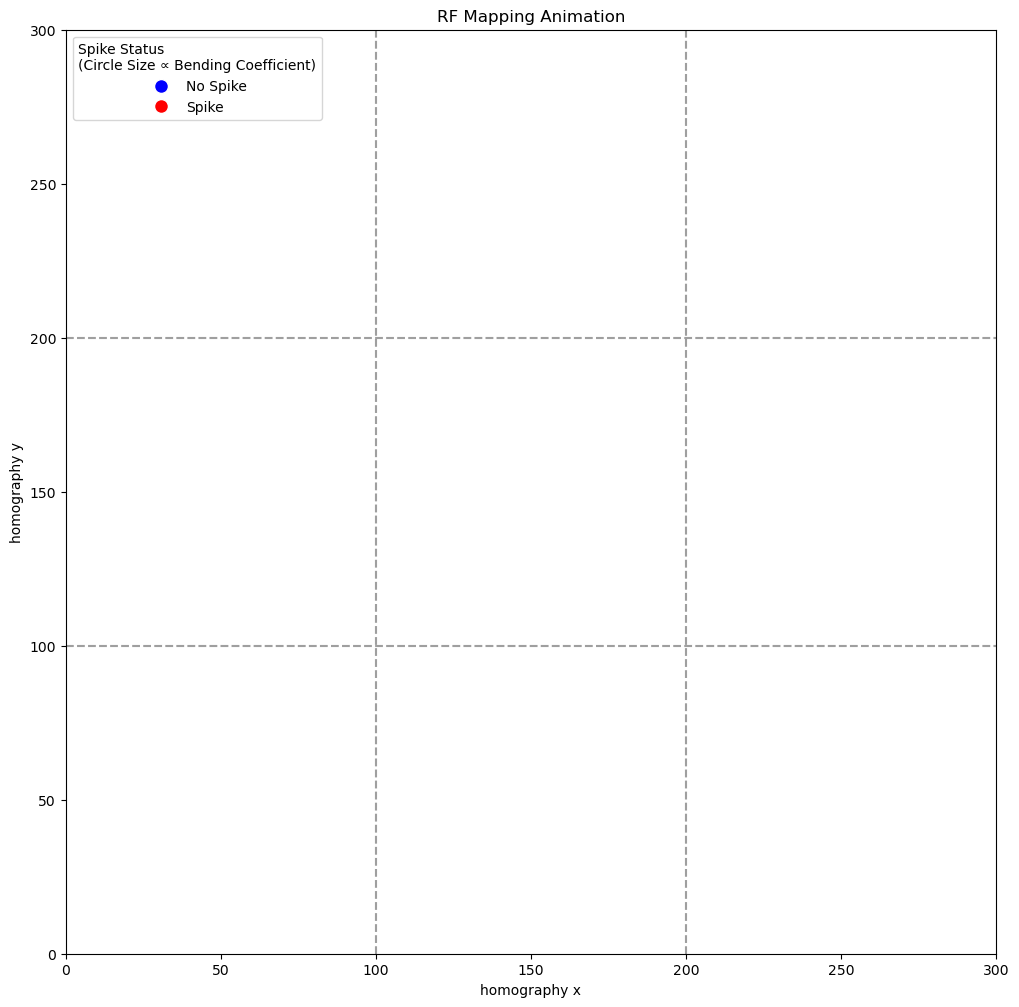

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:182: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), size, color=color, alpha=0.5, edgecolor="k", linewidth=0.5)


In [ ]:
Plotting.plot_rf_mapping_animated(full_data.df_merged,
                                  "tf_FB2_x", "tf_FB2_y",
                                  "Bending_Coefficient",
                                  "Spikes",
                                  full_data.dlc.homography_points,
                                  "rf_mapping_animation_3740.mp4")

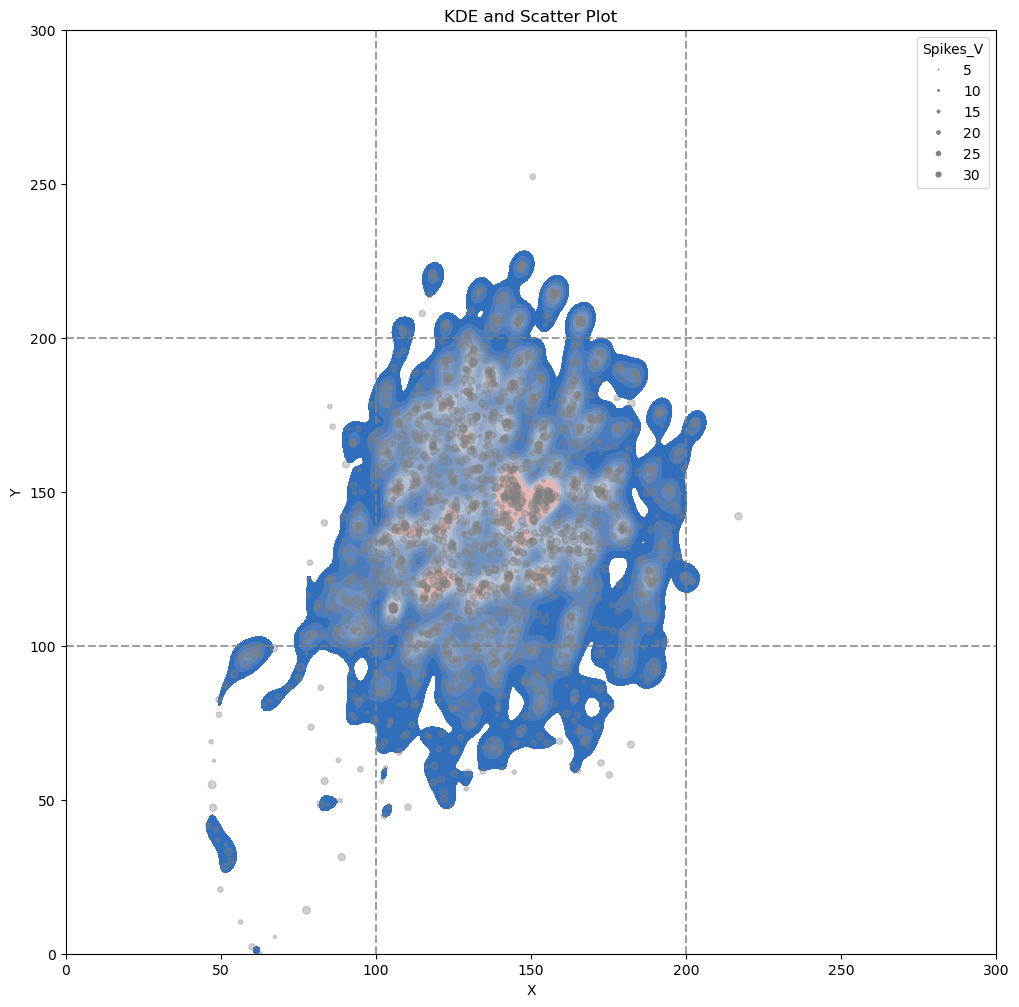

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'KDE and Scatter Plot'}, xlabel='X', ylabel='Y'>)

In [19]:
Plotting.plot_kde_scatter(full_data.df_merged,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          "Freq_Hz",
                          size = "Spikes_V")

In [21]:
index = 5
h_matrix = data_dlc._get_homography_matrix(index)

In [40]:
import pandas as pd
import numpy as np
import cv2
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_ax(ax,
                dfs: tuple,
                x_col,
                y_col,
                size_col, sizes):
    sns.scatterplot(x=x_col, y=y_col, 
                    size=size_col, sizes=sizes,
                    alpha=0.3, edgecolor=None,
                    data=dfs[0], color='blue', ax=ax)
    sns.scatterplot(x=x_col, y=y_col,
                    size=size_col, sizes=sizes,
                    alpha=0.3, edgecolor=None,
                    data=dfs[1], color='red', ax=ax)
    sns.scatterplot(x=x_col, y=y_col,
                    size=size_col, sizes=sizes,
                    alpha=0.3, edgecolor=None,
                    data=dfs[2], color='green', ax=ax)
    
    # color legend, blue = high bend w neuron, red = high bed w/o neuron, green = low bend w neuron
    legend_elements = [Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='blue',
                                markersize=10,
                                label='High Bend & Neuron'),
                        Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='red',
                                markersize=10,
                                label='High Bend & no Neuron'),
                        Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='green',
                                markersize=10,
                                label='Low Bend & Neuron')]
    
    ax.legend(handles=legend_elements,
              title='Bending Coefficient and Neuron Cases',
              loc='upper left')

def plot_kde_scatter_over_frame(merged_data: MergedData,
                                h_matrix: np.ndarray,
                                video_path: str,
                                index: int,
                                x_col: str, y_col: str,
                                homography_points: np.ndarray,
                                kde: bool = True,
                                scatter: bool = True,
                                size: str = "IFF",
                                title: str = 'KDE and Scatter Plot',
                                xlabel: str = 'X', ylabel: str = 'Y',
                                figsize=(12, 12)):
    
    # Load the video frame
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Error: Could not read video frame.")
        return

    # Convert BGR (OpenCV) to RGB (Matplotlib)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Warp the frame using the homography matrix
    h, w, _ = frame.shape
    frame_transformed = cv2.warpPerspective(frame, h_matrix, (w, h))

    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Show the transformed frame in the background
    ax.imshow(frame_transformed)

    # Overlay KDE + scatter plot
    if kde:
        sns.kdeplot(x=df[x_col], y=df[y_col],
                    fill=True,
                    cmap='vlag',
                    bw_adjust=0.3,
                    ax=ax,
                    alpha=0.5)
    if scatter:
        sizes = np.arange(5, 50, 5)
        scatter_ax(ax, merged_data.plotting_split(), x_col, y_col, size, sizes)

        # Create a legend for the scatter plot sizes
        legend_elements = [Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor='gray',
                                    markersize=np.sqrt(s),
                                    label=f'{s}')
                            for s in sizes]
        ax.legend(handles=legend_elements, title=size, loc='upper right')
        

    ax.set_xlim(0, 300)
    ax.set_ylim(0, 300)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    for point in homography_points:
                ax.axhline(y=point[1], color='gray', linestyle='--', alpha=0.5)
                ax.axvline(x=point[0], color='gray', linestyle='--', alpha=0.5)

    plt.show()
    return fig, ax

AttributeError: 'DataFrame' object has no attribute 'plotting_split'

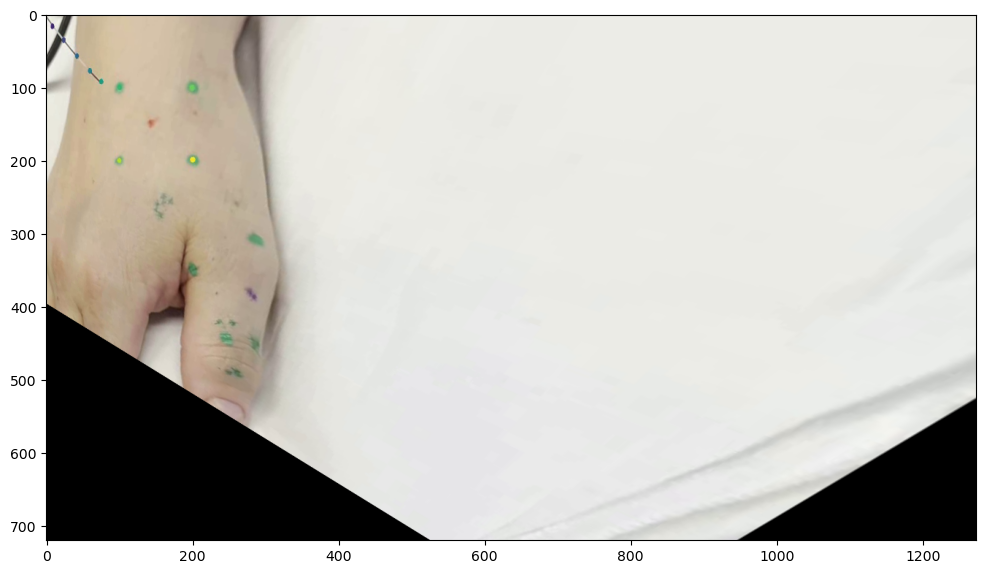

In [42]:
plot_kde_scatter_over_frame(
    full_data.df_merged,
    h_matrix,
    r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3740_convertedDLC_Resnet50_td_res_3Mar18shuffle1_detector_200_snapshot_075_p50_labeled.mp4",
    index,
    "tf_FB2_x", "tf_FB2_y",
    full_data.dlc.homography_points,
    size = "Freq_Hz",
    kde=False,
    scatter=True,
)